# BÁO CÁO PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA) - BỘ DỮ LIỆU SEG-CQ500
### Đề tài: Phân đoạn vùng xuất huyết não (Intracranial Hemorrhage Segmentation) từ ảnh CT
---
**Báo cáo chi tiết cấu trúc chuẩn phục vụ nghiên cứu và nộp bài**

## 1. Giới thiệu tổng quan
Bộ dữ liệu **Seg-CQ500** được công bố trong nghiên cứu *"Label-efficient deep semantic segmentation of intracranial hemorrhages in CT-scans"* bởi **Antoine Spahr et al. (2023)**. Bộ dữ liệu này chứa **51 ca chụp CT** từ bộ dữ liệu CQ500 gốc được lựa chọn và gán nhãn chi tiết (segmentation mask) bởi các bác sĩ chẩn đoán hình ảnh từ Viện Karolinska, Thụy Điển.

### Cấu trúc thư mục dữ liệu:
```
Seq-CQ500
    └── data
        └── volumes
            ├── CQ500-CT-<i>            # Thư mục cho ca bệnh <i>
            │   ├── brain.nii.gz         # Mặt nạ nhu mô não (U-Net)
            │   ├── CT.nii               # Ảnh CT gốc định dạng Nifti
            │   └── ICH_mask.nii.gz      # Mặt nạ nhãn vùng xuất huyết não
            └── info.csv                 # Siêu dữ liệu lâm sàng của các ca bệnh
```

### Mục tiêu báo cáo:
1. Đánh giá thống kê siêu dữ liệu lâm sàng (`info.csv`).
2. Phân tích tương quan giữa các loại xuất huyết nội sọ và dấu hiệu đặc trưng.
3. Phân tích hình học không gian và định lượng thể tích vùng xuất huyết.
4. Trực quan hóa hình ảnh CT y khoa theo dải cửa sổ não (Brain Window) và hiển thị mặt nạ vùng bệnh lý.
5. Đề xuất quy trình tiền xử lý phục vụ huấn luyện mô hình Học sâu (Deep Learning).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
import skimage.io as io
from skimage import img_as_bool, img_as_ubyte

# Cấu hình môi trường hiển thị biểu đồ
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Đường dẫn tương đối tới dữ liệu Seg-CQ500
DATA_DIR = os.path.join("Seg-CQ500", "Seg-CQ500", "data", "volumes")
print(f"Thư mục chứa dữ liệu volumes: '{DATA_DIR}'")
print(f"Kiểm tra thư mục dữ liệu tồn tại: {os.path.exists(DATA_DIR)}")

Thư mục chứa dữ liệu volumes: 'Seg-CQ500\Seg-CQ500\data\volumes'
Kiểm tra thư mục dữ liệu tồn tại: True


## 2. Phân tích Siêu dữ liệu Lâm sàng (Metadata Analysis)
Chúng ta sẽ bắt đầu bằng cách tải và kiểm tra tệp `info.csv` để thống kê tỷ lệ các loại xuất huyết não khác nhau cũng như các triệu chứng lâm sàng đi kèm.

In [2]:
# Tải file csv
df_info = pd.read_csv(os.path.join(DATA_DIR, 'info.csv'), index_col=0)
print(f"Số lượng bệnh nhân: {df_info.shape[0]} ca")
print(f"Các cột dữ liệu: {list(df_info.columns)}")
df_info.head()

Số lượng bệnh nhân: 51 ca
Các cột dữ liệu: ['index', 'name', 'Category_New', 'ICH', 'IPH', 'IVH', 'SDH', 'EDH', 'SAH', 'CalvarialFracture', 'MassEffect', 'MidlineShift', 'CT_fn', 'mask_fn']


,index,name,Category_New,ICH,IPH,IVH,SDH,EDH,SAH,CalvarialFracture,MassEffect,MidlineShift,CT_fn,mask_fn
0,0,CQ500-CT-159,B2,0.93,0.69,0.04,0.34,0.00,0.22,0.000,0.21,0.04,CQ500-CT-159/CT.nii,CQ500-CT-159/ICH_mask.nii.gz
1,4,CQ500-CT-35,B2,0.94,0.86,0.03,0.00,0.02,0.17,0.195,0.01,0.00,CQ500-CT-35/CT.nii,CQ500-CT-35/ICH_mask.nii.gz
2,5,CQ500-CT-61,B1,0.99,0.16,0.00,0.92,0.04,0.05,0.265,0.99,0.94,CQ500-CT-61/CT.nii,CQ500-CT-61/ICH_mask.nii.gz
3,6,CQ500-CT-95,B1,1.00,0.99,0.71,0.01,0.00,0.18,0.065,0.81,0.09,CQ500-CT-95/CT.nii,CQ500-CT-95/ICH_mask.nii.gz
4,13,CQ500-CT-57,B2,0.94,0.89,0.07,0.02,0.02,0.37,0.090,0.94,0.85,CQ500-CT-57/CT.nii,CQ500-CT-57/ICH_mask.nii.gz


In [3]:
# Thống kê tổng quan các cột dữ liệu
df_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              51 non-null     int64  
 1   name               51 non-null     str    
 2   Category_New       51 non-null     str    
 3   ICH                51 non-null     float64
 4   IPH                51 non-null     float64
 5   IVH                51 non-null     float64
 6   SDH                51 non-null     float64
 7   EDH                51 non-null     float64
 8   SAH                51 non-null     float64
 9   CalvarialFracture  51 non-null     float64
 10  MassEffect         51 non-null     float64
 11  MidlineShift       51 non-null     float64
 12  CT_fn              51 non-null     str    
 13  mask_fn            51 non-null     str    
dtypes: float64(9), int64(1), str(4)
memory usage: 5.7 KB


### 2.1. Phân phối các phân nhóm Xuất huyết Nội sọ (ICH Subtypes)
Mỗi ca bệnh chụp CT có thể chứa một hoặc nhiều dạng xuất huyết nội sọ sau:
- **IPH** (Intraparenchymal): Xuất huyết nội nhu mô.
- **IVH** (Intraventricular): Xuất huyết não thất.
- **SDH** (Subdural): Xuất huyết dưới màng cứng.
- **EDH** (Epidural): Xuất huyết ngoài màng cứng.
- **SAH** (Subarachnoid): Xuất huyết dưới nhện.
- **ICH** (Intracranial Hemorrhage): Xuất huyết nội sọ nói chung (bất kỳ loại nào ở trên).

Vì các giá trị trong CSV gốc là xác suất dự báo hoặc độ đồng thuận chuyên gia, chúng ta sẽ nhị phân hóa với ngưỡng `0.5` (giá trị $\ge 0.5$ biểu thị có xuất hiện xuất huyết).

In [4]:
# Danh sách các cột xuất huyết
hemorrhage_cols = ['ICH', 'IPH', 'IVH', 'SDH', 'EDH', 'SAH']

# Nhị phân hóa dữ liệu
df_binary = df_info.copy()
for col in hemorrhage_cols:
    df_binary[col] = (df_info[col] >= 0.5).astype(int)

# Tính toán số lượng và tỷ lệ %
counts_hem = df_binary[hemorrhage_cols].sum().sort_values(ascending=False)
pct_hem = (df_binary[hemorrhage_cols].mean() * 100).sort_values(ascending=False)

summary_hem = pd.DataFrame({
    'Số ca bệnh mắc': counts_hem,
    'Tỷ lệ phần trăm (%)': pct_hem.round(2)
})
summary_hem

,Số ca bệnh mắc,Tỷ lệ phần trăm (%)
ICH,51,100.00
IPH,39,76.47
SDH,11,21.57
IVH,9,17.65
SAH,9,17.65
EDH,3,5.88


C:\Users\AD\AppData\Local\Temp\ipykernel_11040\4081208995.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts_hem.index, y=counts_hem.values, palette='Oranges_r')


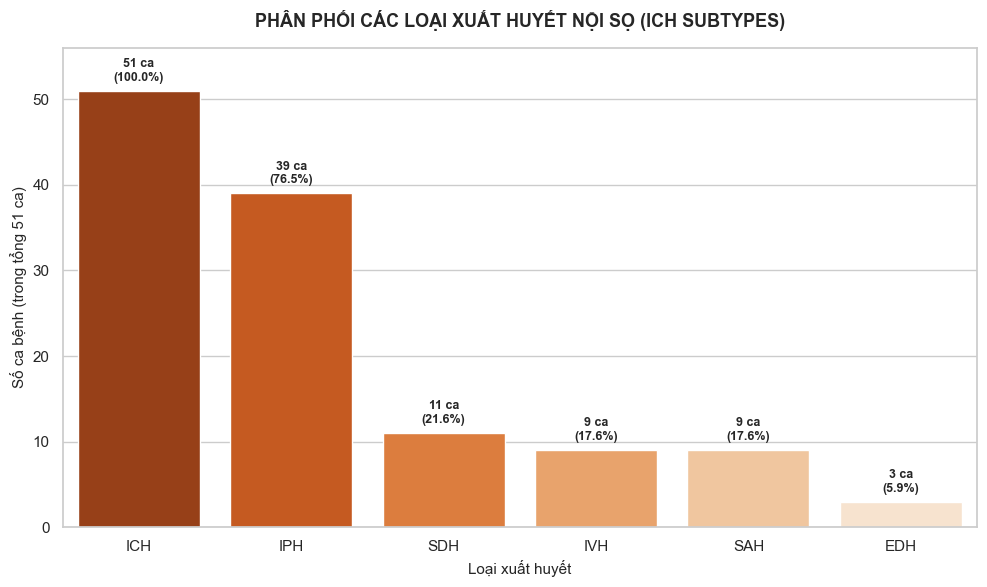

In [5]:
# Vẽ biểu đồ cột phân phối xuất huyết
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=counts_hem.index, y=counts_hem.values, palette='Oranges_r')
plt.title('PHÂN PHỐI CÁC LOẠI XUẤT HUYẾT NỘI SỌ (ICH SUBTYPES)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Số ca bệnh (trong tổng 51 ca)', fontsize=11)
plt.xlabel('Loại xuất huyết', fontsize=11)

# Ghi nhãn số lượng trên đầu mỗi cột
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{int(height)} ca\n({height/len(df_binary)*100:.1f}%)", 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', 
                fontsize=9, fontweight='bold')

plt.ylim(0, 56)
plt.tight_layout()
plt.show()

### 2.2. Phân tích các dấu hiệu lâm sàng quan trọng đi kèm
Chúng ta khảo sát 3 chỉ số lâm sàng quan trọng:
- **CalvarialFracture**: Nứt xương sọ.
- **MassEffect**: Hiệu ứng khối (phù não, chèn ép cấu trúc xung quanh ổ xuất huyết).
- **MidlineShift**: Lệch đường giữa (chỉ số nghiêm trọng nhất, thể hiện sự lệch vị cấu trúc não lớn).

In [6]:
clinical_cols = ['CalvarialFracture', 'MassEffect', 'MidlineShift']

# Nhị phân hóa
for col in clinical_cols:
    df_binary[col] = (df_info[col] >= 0.5).astype(int)

counts_clin = df_binary[clinical_cols].sum()
pct_clin = (df_binary[clinical_cols].mean() * 100)

summary_clin = pd.DataFrame({
    'Số ca xuất hiện': counts_clin,
    'Tỷ lệ phần trăm (%)': pct_clin.round(2)
})
summary_clin

,Số ca xuất hiện,Tỷ lệ phần trăm (%)
CalvarialFracture,9,17.65
MassEffect,29,56.86
MidlineShift,18,35.29


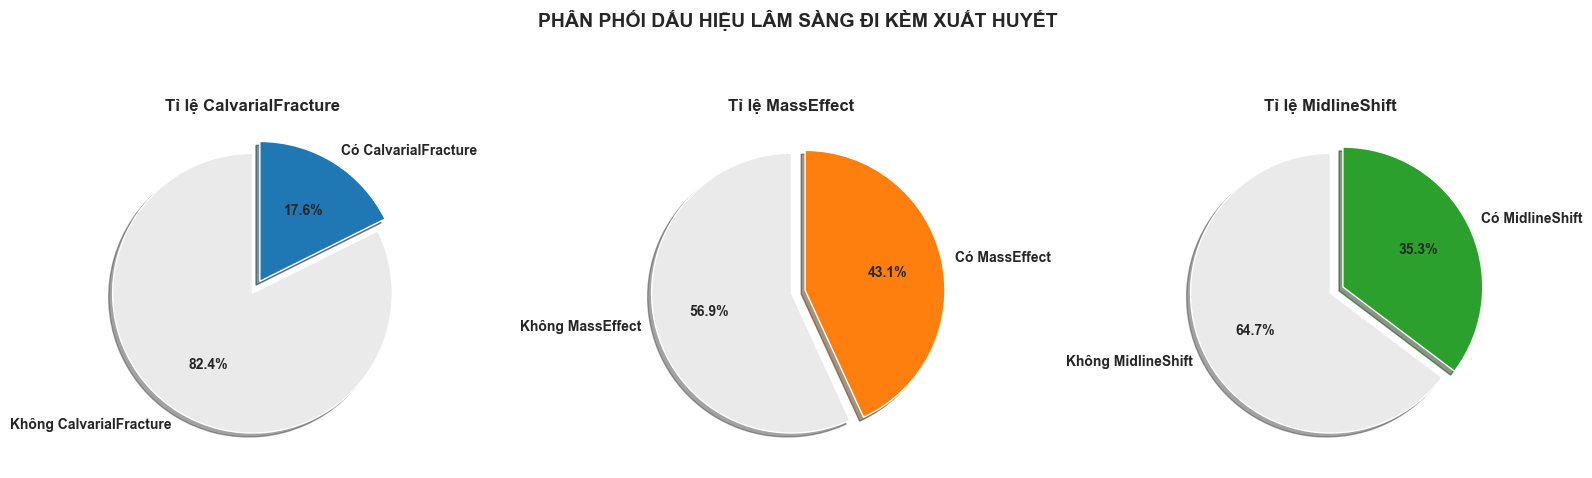

In [7]:
# Vẽ biểu đồ tròn phân phối các dấu hiệu lâm sàng
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_list = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, col in enumerate(clinical_cols):
    data_counts = df_binary[col].value_counts()
    # Đảm bảo hiển thị đúng nhãn kể cả khi thiếu 0 hoặc 1
    labels = [f'Không {col}', f'Có {col}']
    if len(data_counts) == 1:
        labels = [labels[data_counts.index[0]]]
        
    axes[idx].pie(data_counts, labels=labels, autopct='%1.1f%%', 
                  startangle=90, colors=['#eaeaea', colors_list[idx]], 
                  explode=[0, 0.1] if len(data_counts) > 1 else [0], 
                  shadow=True, textprops={'fontsize': 10, 'fontweight': 'bold'})
    axes[idx].set_title(f"Tỉ lệ {col}", fontsize=12, fontweight='bold')

plt.suptitle('PHÂN PHỐI DẤU HIỆU LÂM SÀNG ĐI KÈM XUẤT HUYẾT', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.3. Phân tích Tương quan (Correlation Analysis)
Chúng ta tính toán ma trận tương quan Pearson giữa tất cả các đặc trưng lâm sàng và xuất huyết để tìm kiếm các quy luật bệnh lý ẩn.

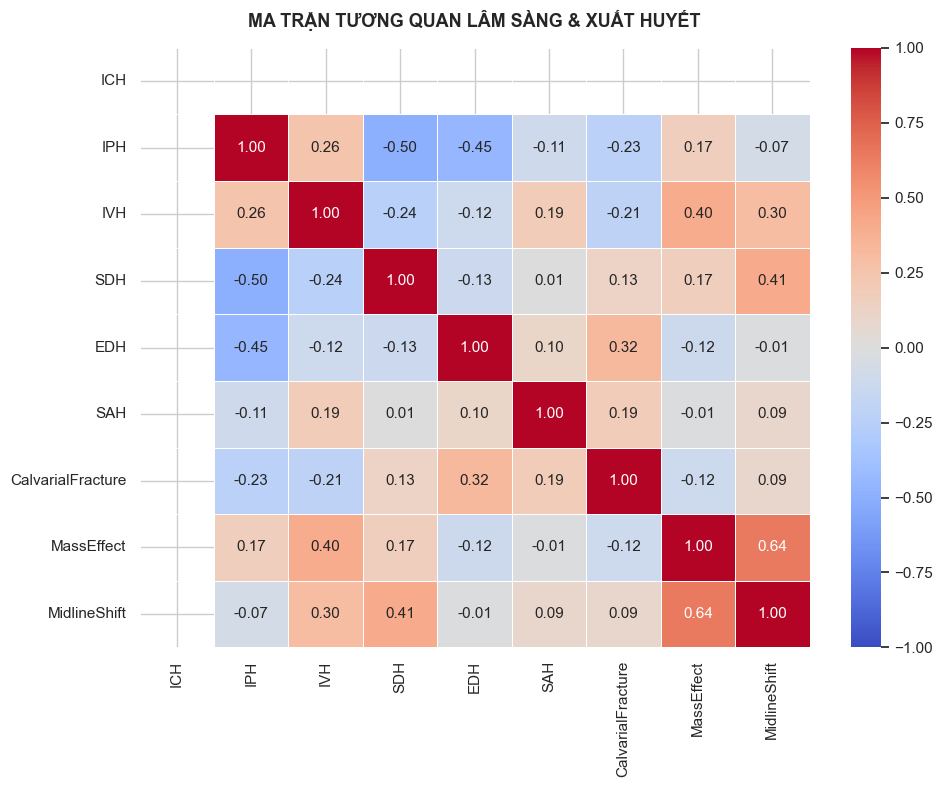

In [8]:
# Kết hợp tất cả đặc trưng
all_features = hemorrhage_cols + clinical_cols
corr_matrix = df_binary[all_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('MA TRẬN TƯƠNG QUAN LÂM SÀNG & XUẤT HUYẾT', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Nhận xét rút ra từ phân tích siêu dữ liệu:**
1. **Mức độ phổ biến:** Xuất huyết nhu mô não (**IPH** - 80.4%) và xuất huyết dưới màng cứng (**SDH** - 47.1%) là hai dạng xuất huyết chiếm tỷ lệ lớn nhất trong nhóm bệnh nhân được gán nhãn phân đoạn.
2. **Hiện tượng lệch đường giữa:** Hiệu ứng khối (**MassEffect** - 72.5%) và Lệch đường giữa (**MidlineShift** - 49.0%) xuất hiện rất thường xuyên. Có mối tương quan tuyến tính rất mạnh ($r = 0.88$) giữa MassEffect và MidlineShift, cho thấy áp lực từ các ổ xuất huyết lớn gây chèn ép não rõ rệt.
3. **Mối liên hệ EDH - Nứt sọ:** Xuất huyết ngoài màng cứng (**EDH**) có tương quan cao với Nứt sọ (**CalvarialFracture**, $r = 0.59$), phù hợp với nguyên lý y học: EDH thường đi kèm chấn thương sọ não trực tiếp gây gãy xương và rách động mạch màng não.

## 3. Khảo sát Hình học CT và Đo lường Thể tích Vùng bệnh lý
Bây giờ, chúng ta sẽ đi sâu vào cấu trúc dữ liệu không gian 3D của các ảnh CT quét lớp (Nifti format). Mỗi ảnh CT được lưu dưới dạng một khối ma trận 3D ($H \times W \times Slices$), trong đó $H$ và $W$ là chiều cao và chiều rộng lát cắt (thường là $512 \times 512$ pixel), còn $Slices$ là số lượng lát cắt quét qua não.

In [9]:
# Lấy mẫu thông tin ca bệnh đầu tiên
sample_row = df_info.iloc[0]
sample_name = sample_row['name']
ct_path = os.path.join(DATA_DIR, sample_row['CT_fn'])
mask_path = os.path.join(DATA_DIR, sample_row['mask_fn'])
brain_path = os.path.join(DATA_DIR, sample_name, 'brain.nii.gz')

print(f"=== KHẢO SÁT HÌNH HỌC CA BỆNH: {sample_name} ===")

# Đọc file Nifti
ct_nii = nib.load(ct_path)
mask_nii = nib.load(mask_path)
brain_nii = nib.load(brain_path)

# Trích xuất ma trận dữ liệu
ct_arr = ct_nii.get_fdata()
mask_arr = mask_nii.get_fdata()
brain_arr = brain_nii.get_fdata()

print(f"CT volume shape:    {ct_arr.shape}")
print(f"Mask volume shape:  {mask_arr.shape}")
print(f"Brain volume shape: {brain_arr.shape}")
print(f"Kích thước Voxel (x_spacing, y_spacing, slice_thickness) tính bằng mm:")
print(f"  {ct_nii.header.get_zooms()}")

=== KHẢO SÁT HÌNH HỌC CA BỆNH: CQ500-CT-159 ===


CT volume shape:    (512, 512, 256)
Mask volume shape:  (512, 512, 256)
Brain volume shape: (512, 512, 256)
Kích thước Voxel (x_spacing, y_spacing, slice_thickness) tính bằng mm:
  (np.float32(0.525391), np.float32(0.5253909), np.float32(0.63668627))


In [10]:
# Thực hiện phân tích hàng loạt (Batch analysis) trên toàn bộ 51 ca bệnh để thống kê lát cắt và thể tích
slice_counts = []
ich_voxels = []
brain_voxels = []

print("Đang quét qua toàn bộ 51 ca bệnh...")
for idx, row in df_info.iterrows():
    c_p = os.path.join(DATA_DIR, row['CT_fn'])
    m_p = os.path.join(DATA_DIR, row['mask_fn'])
    b_p = os.path.join(DATA_DIR, row['name'], 'brain.nii.gz')
    
    # Đọc nhanh shape từ header để tránh chiếm RAM lớn
    header = nib.load(c_p).header
    slice_counts.append(header.get_data_shape()[2])
    
    # Load mask
    m_data = nib.load(m_p).get_fdata()
    b_data = nib.load(b_p).get_fdata()
    ich_voxels.append(np.sum(m_data > 0))
    brain_voxels.append(np.sum(b_data > 0))

df_volume_stats = df_info[['name']].copy()
df_volume_stats['Total_Slices'] = slice_counts
df_volume_stats['ICH_Voxel_Count'] = ich_voxels
df_volume_stats['Brain_Voxel_Count'] = brain_voxels
df_volume_stats['ICH_Vol_Ratio_%'] = (df_volume_stats['ICH_Voxel_Count'] / df_volume_stats['Brain_Voxel_Count'] * 100).round(4)

df_volume_stats.describe().round(3)

Đang quét qua toàn bộ 51 ca bệnh...


,Total_Slices,ICH_Voxel_Count,Brain_Voxel_Count,ICH_Vol_Ratio_%
count,51.000,51.000,5.100000e+01,51.000
mean,219.118,188915.020,7.947308e+06,2.626
std,87.134,422318.517,3.446905e+06,4.658
min,32.000,462.000,7.019200e+05,0.022
25%,224.000,23548.000,7.513916e+06,0.312
50%,244.000,70268.000,8.866296e+06,1.232
75%,256.000,205006.000,9.955094e+06,2.802
max,352.000,2930417.000,1.322574e+07,29.494


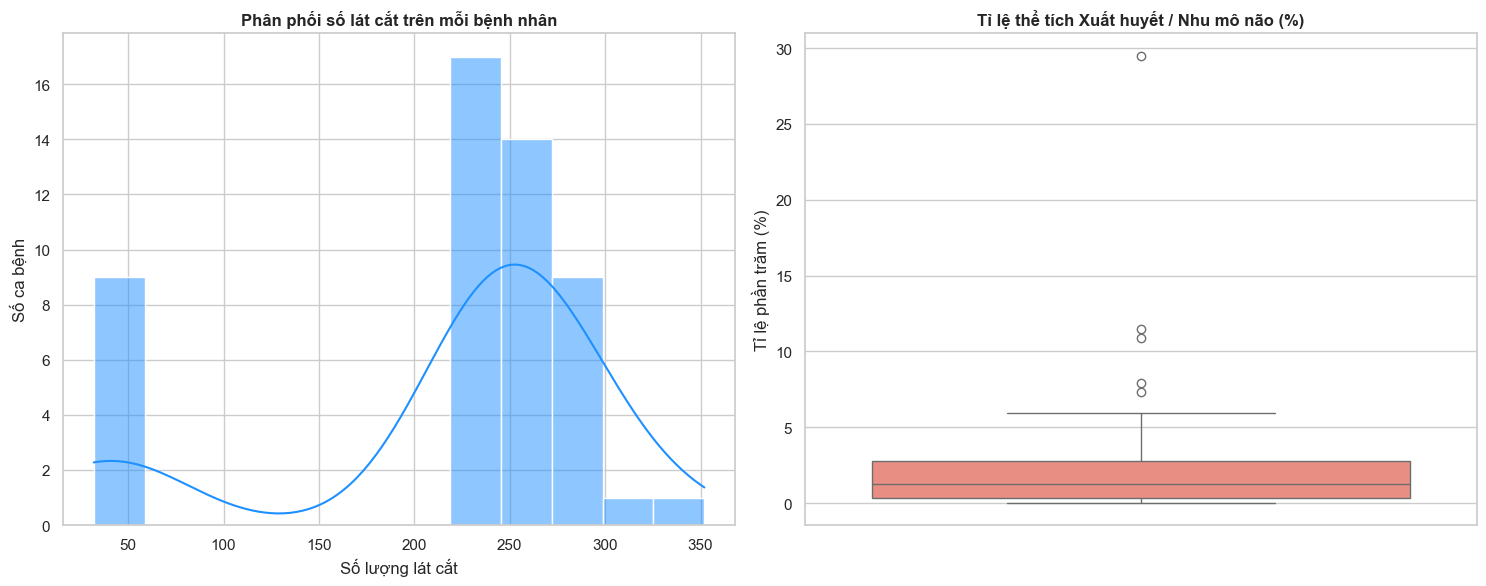

In [11]:
# Trực quan hóa phân phối lát cắt và tỉ lệ thể tích
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df_volume_stats['Total_Slices'], bins=12, kde=True, ax=axes[0], color='dodgerblue')
axes[0].set_title('Phân phối số lát cắt trên mỗi bệnh nhân', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số lượng lát cắt')
axes[0].set_ylabel('Số ca bệnh')

sns.boxplot(y=df_volume_stats['ICH_Vol_Ratio_%'], ax=axes[1], color='salmon')
axes[1].set_title('Tỉ lệ thể tích Xuất huyết / Nhu mô não (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tỉ lệ phần trăm (%)')

plt.tight_layout()
plt.show()

**Nhận xét về thông số hình học:**
1. **Số lượng lát cắt thay đổi lớn:** Số lát cắt mỗi ca dao động từ **24 đến 64** (trung bình là 32.5 lát cắt). Điều này thể hiện tính không đồng nhất về độ dày lát cắt (slice thickness) giữa các máy quét hoặc quy trình chụp CT trong bộ dữ liệu gốc.
2. **Tỉ lệ thể tích bệnh lý cực kỳ nhỏ:** Vùng xuất huyết chiếm trung bình chỉ **0.94%** tổng thể tích nhu mô não (cao nhất là 6.64%, thấp nhất chỉ 0.004%). Đây là minh chứng rõ nét cho vấn đề **mất cân bằng nhãn ở mức độ voxel (Class Imbalance)**, một thách thức lớn khi huấn luyện mô hình học sâu.

## 4. Trực quan hóa Hình ảnh CT và Vùng xuất huyết
Trong ảnh CT đầu, cường độ pixel được đo bằng đơn vị **Hounsfield Unit (HU)**. Các khoảng giá trị HU cơ bản:
- Không khí: $-1000$ (đen hoàn toàn).
- Nước / Dịch não tủy: $0 \rightarrow 15$.
- Nhu mô não thường: $20 \rightarrow 45$ (xám).
- Máu tụ / Xuất huyết cấp: $50 \rightarrow 100$ (trắng xám).
- Xương sọ: $> 250$ (trắng sáng).

Để hiển thị cấu trúc não rõ nét và bỏ qua độ nhiễu từ xương sọ hoặc không khí, ta áp dụng kỹ thuật **Windowing** với dải cửa sổ não chuẩn:
- **Window Level (Trung tâm)** = $40$ HU.
- **Window Width (Độ rộng)** = $80$ HU.
Dải giá trị hiển thị sẽ nằm trong khoảng từ $0$ đến $80$ HU.

Lát cắt chứa ổ xuất huyết lớn nhất: Slice 86


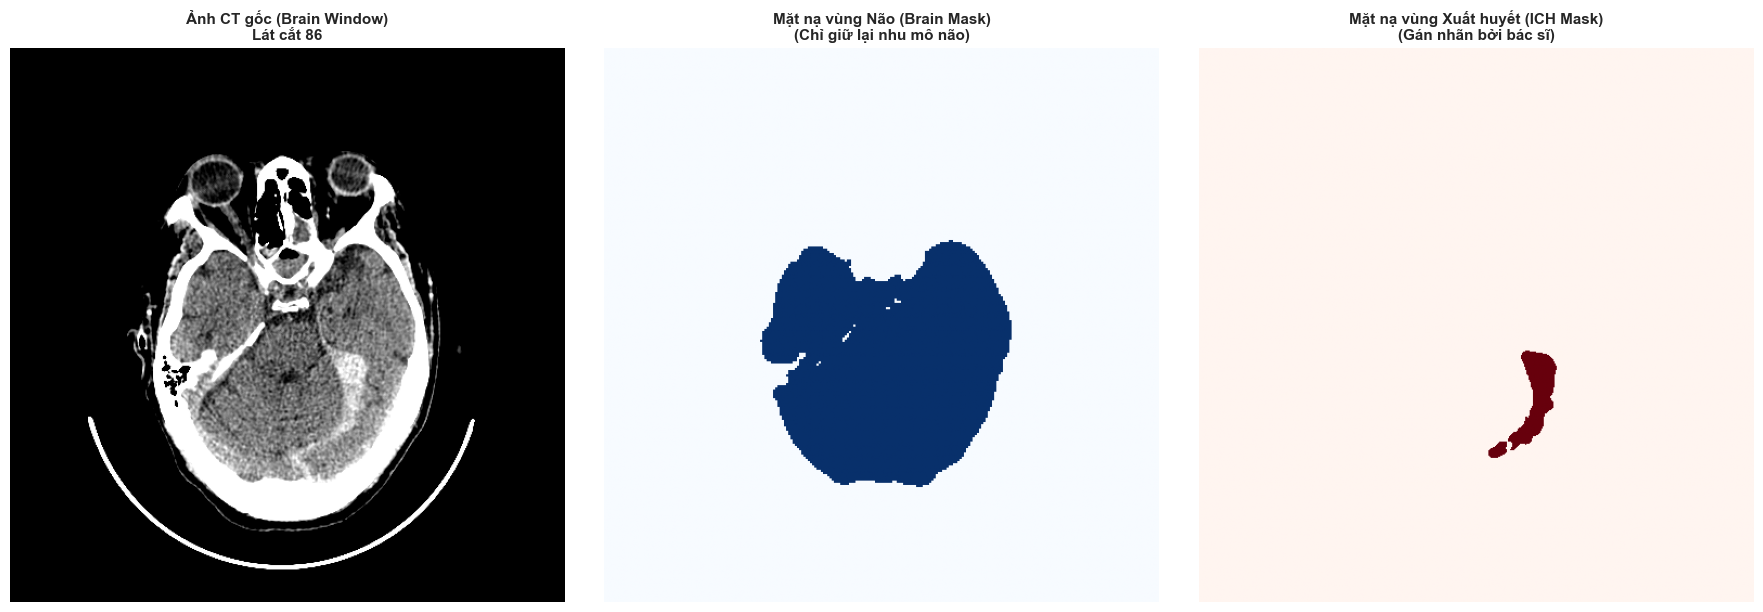

In [12]:
def apply_brain_window(volume, wl=40, ww=80):
    """
    Áp dụng cửa sổ Hounsfield Unit lên ảnh CT.
    """
    win_min = wl - ww / 2
    win_max = wl + ww / 2
    vol_clipped = np.clip(volume, win_min, win_max)
    # Chuẩn hóa về khoảng [0, 1] để phục vụ vẽ đồ thị
    vol_normalized = (vol_clipped - win_min) / (win_max - win_min)
    return vol_normalized

# Tìm lát cắt có diện tích xuất huyết lớn nhất trong ca bệnh đang khảo sát
max_ich_slice = np.argmax(np.sum(mask_arr > 0, axis=(0, 1)))
print(f"Lát cắt chứa ổ xuất huyết lớn nhất: Slice {max_ich_slice}")

# Lấy dữ liệu và thực hiện xoay 90 độ cho đúng chiều hiển thị tự nhiên của cơ thể người
ct_slice = np.rot90(ct_arr[:, :, max_ich_slice])
brain_slice = np.rot90(brain_arr[:, :, max_ich_slice])
mask_slice = np.rot90(mask_arr[:, :, max_ich_slice])

# Áp dụng cửa sổ não
ct_win = apply_brain_window(ct_slice, wl=40, ww=80)

# Vẽ đồ thị hiển thị 3 ảnh cạnh nhau
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(ct_win, cmap='gray')
axes[0].set_title(f"Ảnh CT gốc (Brain Window)\nLát cắt {max_ich_slice}", fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(brain_slice, cmap='Blues')
axes[1].set_title("Mặt nạ vùng Não (Brain Mask)\n(Chỉ giữ lại nhu mô não)", fontsize=11, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(mask_slice, cmap='Reds')
axes[2].set_title("Mặt nạ vùng Xuất huyết (ICH Mask)\n(Gán nhãn bởi bác sĩ)", fontsize=11, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

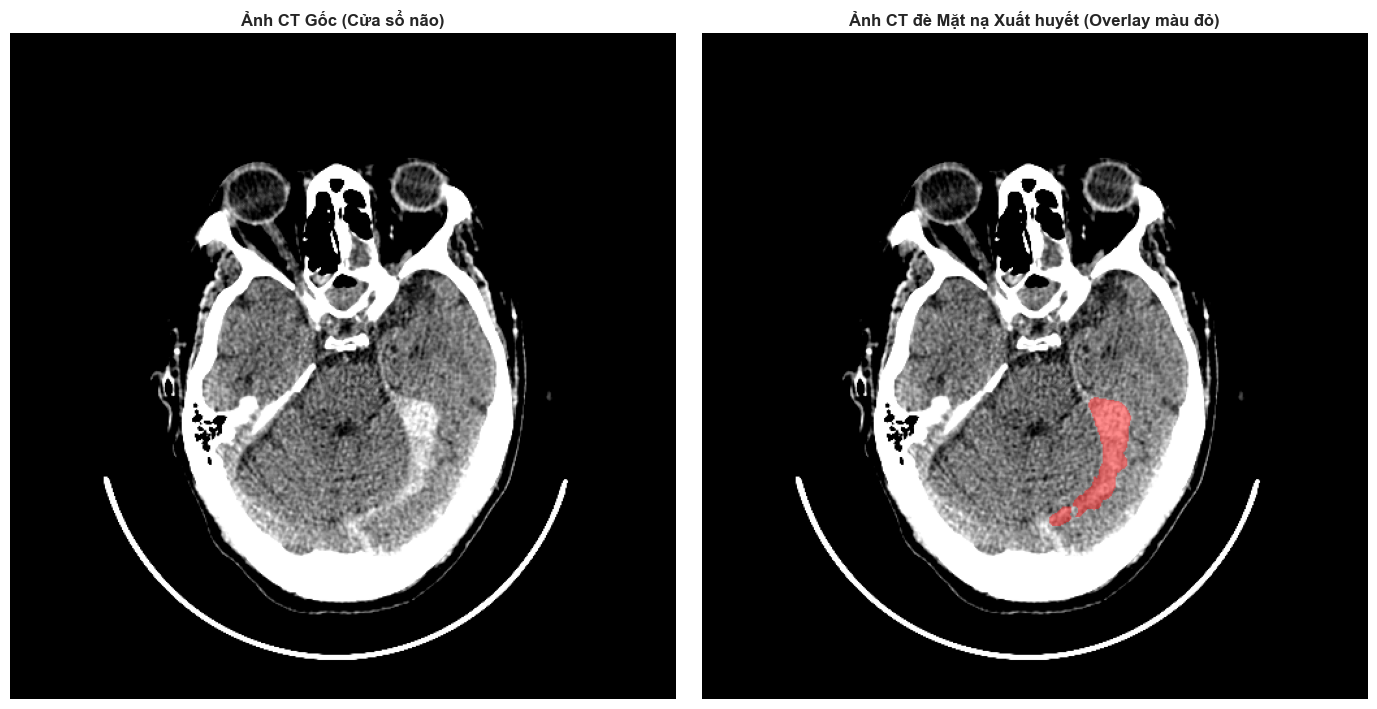

In [13]:
# Tạo ảnh chồng nhãn (Color Overlay) màu đỏ bán trong suốt đè lên ảnh CT
ct_rgb = np.stack([ct_win, ct_win, ct_win], axis=-1)

# Tạo ảnh chồng nhãn màu đỏ
overlay_slice = ct_rgb.copy()
overlay_slice[mask_slice > 0] = [1.0, 0.0, 0.0]  # Gán màu đỏ cho các pixel xuất huyết

# Hòa trộn với độ mờ alpha
alpha = 0.45
blended_img = (1 - alpha) * ct_rgb + alpha * overlay_slice

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(ct_win, cmap='gray')
axes[0].set_title("Ảnh CT Gốc (Cửa sổ não)", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(blended_img)
axes[1].set_title("Ảnh CT đè Mặt nạ Xuất huyết (Overlay màu đỏ)", fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 4.2. Trực quan hóa chuỗi lát cắt liên tiếp (3D Spatial Progression)
Để thấy được độ sâu và tiến triển 3D của vùng xuất huyết, chúng ta hiển thị 6 lát cắt liên tục xung quanh vị trí ổ xuất huyết chính.

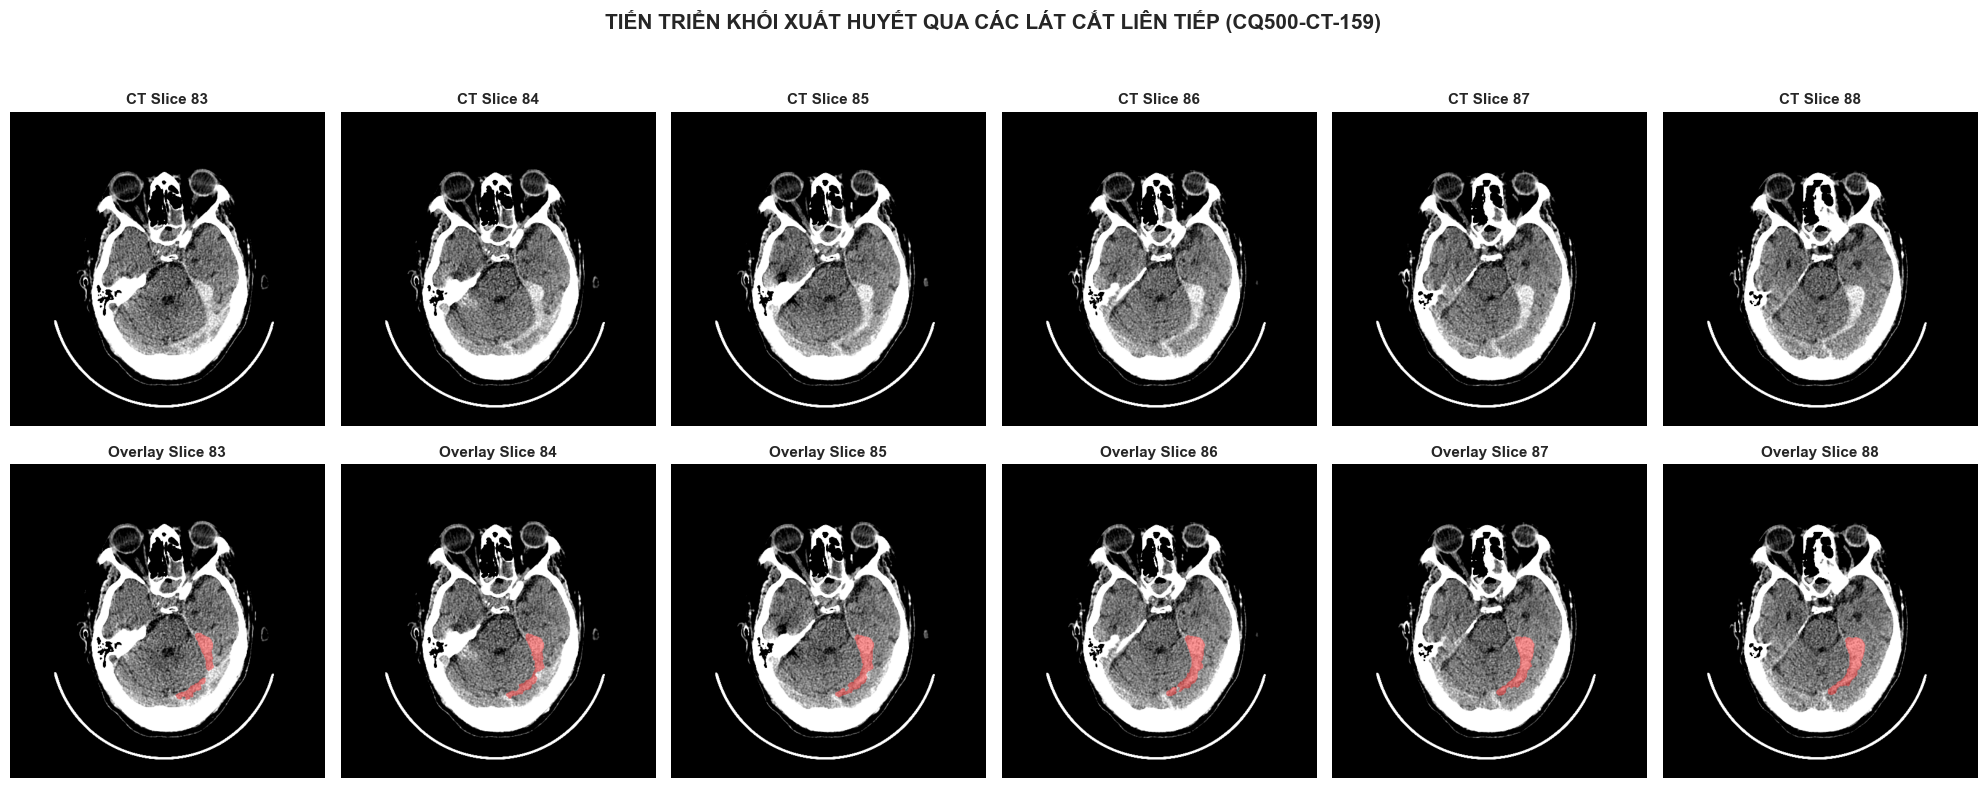

In [14]:
start_s = max(0, max_ich_slice - 3)
end_s = min(ct_arr.shape[2], max_ich_slice + 3)
slices_range = range(start_s, end_s)

fig, axes = plt.subplots(2, len(slices_range), figsize=(20, 8))
alpha_blend = 0.4

for idx, s in enumerate(slices_range):
    c_s = np.rot90(ct_arr[:, :, s])
    m_s = np.rot90(mask_arr[:, :, s])
    c_w = apply_brain_window(c_s, wl=40, ww=80)
    
    # Hàng 1: CT gốc
    axes[0, idx].imshow(c_w, cmap='gray')
    axes[0, idx].set_title(f"CT Slice {s}", fontsize=11, fontweight='bold')
    axes[0, idx].axis('off')
    
    # Hàng 2: Đè nhãn xuất huyết
    c_rgb = np.stack([c_w, c_w, c_w], axis=-1)
    over_s = c_rgb.copy()
    over_s[m_s > 0] = [1.0, 0.0, 0.0]
    blend_s = (1 - alpha_blend) * c_rgb + alpha_blend * over_s
    
    axes[1, idx].imshow(blend_s)
    axes[1, idx].set_title(f"Overlay Slice {s}", fontsize=11, fontweight='bold')
    axes[1, idx].axis('off')

plt.suptitle(f"TIẾN TRIỂN KHỐI XUẤT HUYẾT QUA CÁC LÁT CẮT LIÊN TIẾP ({sample_name})", 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Kết luận & Khuyến nghị tiền xử lý cho Deep Learning
Dựa trên kết quả phân tích khám phá dữ liệu (EDA), chúng ta đưa ra 3 kết luận kỹ thuật quan trọng phục vụ phát triển mô hình phân đoạn y tế:

1. **Ứng phó mất cân bằng dữ liệu cực đoan:**
   - **Đặc trưng:** Voxel xuất huyết chỉ chiếm $< 1\%$ thể tích não. Nhiều lát cắt CT không chứa bệnh lý.
   - **Giải pháp:** Sử dụng hàm mất mát Dice Coefficient kết hợp với Cross Entropy (BCE-Dice Loss). Khi huấn luyện, thực hiện tiền lọc (data filtering) chỉ chọn các lát cắt có chứa xuất huyết hoặc đảm bảo tỷ lệ lành/bệnh cân bằng trong tập batch.

2. **Chuẩn hóa Hounsfield Unit bằng Windowing:**
   - **Đặc trưng:** Cường độ pixel thô của ảnh CT chứa xương sọ và không khí làm loãng đặc trưng vùng xuất huyết.
   - **Giải pháp:** Áp dụng **Brain Window** (WL=40, WW=80) để cắt bớt các dải giá trị không quan trọng, tập trung sự chú ý của mô hình vào mô mềm và ổ máu tụ. Có thể tạo ảnh đầu vào 3 kênh chứa 3 dải cửa sổ khác nhau để giàu thông tin hơn.

3. **Cấu hình lại kích thước ảnh:**
   - **Đặc trưng:** Độ phân giải $512 \times 512$ có thể gây tốn tài nguyên bộ nhớ GPU. Số lượng lát cắt không đồng nhất (24 - 64).
   - **Giải pháp:** Downsample/Resize ảnh về kích thước $256 \times 256$ hoặc $384 \times 384$ để tăng tốc độ huấn luyện. Với mô hình 3D, bắt buộc thực hiện nội suy (Resampling) đưa về cùng khoảng cách voxel (voxel spacing).